# Big Data Analysis of News Headlines and Stock Market Volatility

**Author**: *Pablo Zavala, MPP*

This Jupyter Notebook is an initial big data analysis of how daily news headlines (from Reddit) might help predict or explain movements in the Dow Jones Industrial Average (DJIA), focusing on feature selection. Specifically, we explore whether certain words in the headlines have predictive power for returns and volatility.  

This analysis applies methods such as:  
- Reading and preparing data (creating sparse matrices for word counts).  
- Marginal screening of words using linear regressions and multiple testing corrections (False Discovery Rate).  
- Lasso variable selection for high-dimensional data (with cross-validation).  
- Causal inference via “Double Lasso” to attempt to isolate the effect of previous volatility on today’s volatility.  
- Bootstrapping to assess the variability of regularization parameters (λ) selected via an information criterion.  

We will combine **Pandas**, **NumPy**, **SciPy**, **scikit-learn**, and **statsmodels** to perform the key tasks:
1. **Reading/cleaning data**  
2. **Creating a sparse word-frequency matrix**  
3. **Descriptive analysis** (histograms, time series)  
4. **Marginal regression** for word-level significance testing, and FDR  
5. **Lasso** for returns and volatility prediction  
6. **Double Lasso** to separate genuine “causal” effects from confounding by words  
7. **Bootstrap** for λ variability  

Throughout this notebook, we will also discuss the economic rationale behind each step, referencing (1) the logic of time-series econometrics, (2) potential macroeconomic or microeconomic interpretations of volatility predictions, and (3) the problem of omitted variable bias in high-dimensional contexts.


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csc_matrix
from scipy import stats
import statsmodels.api as sm

from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from joblib import Parallel, delayed  # for parallel computations

# Set aesthetic parameters
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## 1. Reading and Exploring the Data

The CSV files used for analysis are the following:
1. **RedditNews.csv** – containing rows of headlines and dates  
2. **DJIA.csv** – containing daily open, high, low, close for the DJIA (and possibly adjusted close, volume, etc.)  
3. **WordsFinal.csv** – containing a list of words used in final analysis  
4. **WordFreqFinal.csv** – a (day, word, count) triple for all words  

Below, we define functions to load each dataset. We will store the daily returns and daily volatility from `DJIA.csv`, read the text data, and build a sparse matrix of word frequencies.  

We will also illustrate a small preview of each dataset.  

In [79]:
# Data Loading Functions
def load_reddit_news(filepath):
    """
    Load the Reddit news data (skipping the header line).
    Returns a DataFrame with columns: ['Date', 'Headline'].
    """
    data = pd.read_csv(filepath, skiprows=1, header=None, names=["Date", "Headline"])
    return data

def load_djia(filepath):
    """
    Load DJIA data from CSV.
    Returns a DataFrame with columns like 'Date','Open','High','Low','Close'... 
    We'll rely on the user having that info.
    """
    dj = pd.read_csv(filepath)
    return dj

def load_words(filepath):
    """
    Loads the list of words from WordsFinal.csv 
    Returns a list of words (strings).
    """
    df = pd.read_csv(filepath, header=None)
    words = df[0].tolist()
    return words

def load_word_freq(filepath):
    """
    Loads the doc_word data from WordFreqFinal.csv.
    We assume each row has three columns: day_index, word_index, count. 
    If your file is tab- or space-delimited, adjust `delimiter` accordingly.
    """
    df = pd.read_csv(filepath, 
                     header=None, 
                     names=["day_index", "word_index", "count"], 
                     delim_whitespace=True)  
    return df

### Load All Data
Now we call these helper functions. We must set all CSV files are in the same directory or specify paths accordingly.

In [6]:
# Load Data
reddit_data = load_reddit_news("RedditNews.csv")
djia = load_djia("DJIA.csv")
words = load_words("WordsFinal.csv")
doc_word = load_word_freq("WordFreqFinal.csv")

print("Reddit Data (head):")
display(reddit_data.head())

print("DJIA Data (head):")
display(djia.head())

print("First few words from WordsFinal:")
print(words[:6])

print("Doc-Word Frequencies (head):")
display(doc_word.head())

Reddit Data (head):


/var/folders/j9/h4q9tmq92y1b9jl4czz22fgw0000gn/T/ipykernel_66238/2867258921.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath,


,Date,Headline
0,7/1/16,IMF chief backs Athens as permanent Olympic host
1,7/1/16,"The president of France says if Brexit won, so..."
2,7/1/16,British Man Who Must Give Police 24 Hours' Not...
3,7/1/16,100+ Nobel laureates urge Greenpeace to stop o...
4,7/1/16,Brazil: Huge spike in number of police killing...


DJIA Data (head):


,Date,Open,High,Low,Close,Volume,Adj Close
0,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234


First few words from WordsFinal:
['ab', 'abandon', 'abba', 'abbott', 'abc', 'abduct']
Doc-Word Frequencies (head):


,day_index,word_index,count
0,1,44,1
1,1,85,1
2,1,86,2
3,1,91,1
4,1,100,1


In [7]:
# Basic checks
ndays = djia.shape[0]
print(f"Number of days in DJIA dataset: {ndays}")

Number of days in DJIA dataset: 1989


## 2. Construct a Sparse Matrix of Word Counts

We'll then build a large sparse matrix `spm` with shape `(ndays, number_of_words)`, where each row corresponds to a day, each column corresponds to a word, and the entries are the counts of that word on that day.  

Then, we will filter out words that occur fewer than 5 times overall, or occur **every** day.  

Finally, for the analysis we remove the last day from the matrix.

In [9]:
# Create Sparse Matrix
from scipy.sparse import coo_matrix

def create_sparse_matrix(doc_word_df, words_list, ndays):
    """
    Create a sparse matrix from doc_word DataFrame.
      - doc_word_df has columns [day_index, word_index, count].
      - words_list is a list of words, length = total number of unique words.
      - ndays is total number of days in the DJIA data.
    
    Returns:
      spm (csc_matrix) with shape (ndays, nwords).
        row i corresponds to day i (0-based).
        column j corresponds to word j (0-based).
    """
    # Convert day_index and word_index to 0-based if needed
    row_idx = doc_word_df["day_index"].values - 1  # now 0-based
    col_idx = doc_word_df["word_index"].values - 1
    data = doc_word_df["count"].values
    
    nwords = len(words_list)
    
    # Build coo_matrix, then convert to csc or csr
    spm_coo = coo_matrix((data, (row_idx, col_idx)), shape=(ndays, nwords))
    spm_csc = spm_coo.tocsc()
    return spm_csc

spm = create_sparse_matrix(doc_word, words, ndays)
print("Initial Shape of spm:", spm.shape)

Initial Shape of spm: (1989, 5271)


### Filter Words
1. Remove words that occur fewer than 5 times in total.  
2. Remove words that occur in every single day.  

Precisely, let $$ \text{colSum}_j = \sum_{i=1}^{\text{ndays}} spm[i,j]. $$ We keep only words with $ \text{colSum}_j > 5 $ and also $ \text{colSum}_j < \text{ndays} $.  

Then, we remove the last row from `spm`.

In [11]:
# Filtering
col_sums = np.array(spm.sum(axis=0)).flatten()  # shape (nwords,)
mask_min_occurs = col_sums > 5
mask_not_everyday = col_sums < ndays

final_mask = mask_min_occurs & mask_not_everyday
spm = spm[:, final_mask]

# also subset the words list
filtered_words = np.array(words)[final_mask]
print("After filtering, shape of spm:", spm.shape)

# Remove the last day
spm = spm[:-1, :]
print("After removing last day, shape of spm:", spm.shape)
ndays_modified = spm.shape[0]

After filtering, shape of spm: (1989, 3183)
After removing last day, shape of spm: (1988, 3183)


## 3. Returns and Volatility

We define:  
- **Returns**: $R_t = \frac{\text{Close}_t - \text{Close}_{t+1}}{\text{Close}_{t+1}}$, which corresponds to day `t` minus day `t+1` over day `t+1`.  
- **Volatility**: $V_t = \log(\text{High}_t - \text{Low}_t)$.  

Then we remove the last day from these series (so that they align with the `spm` shape).  

In [13]:
# Create returns R and volatility V

djia["Date"] = pd.to_datetime(djia.iloc[:,0])  # parse date

# returns for day t (through day t in spm) 
# compare close[t] vs close[t+1]
close_prices = djia.iloc[:,4].values  # the 'Close' column
R = (close_prices[:-1] - close_prices[1:]) / close_prices[1:]

# volatility for day t
high_prices = djia.iloc[:,2].values
low_prices  = djia.iloc[:,3].values
V = np.log(high_prices[:-1] - low_prices[:-1])


print("Length of R:", len(R))
print("Length of V:", len(V))

# Test for stationarity
from statsmodels.tsa.stattools import adfuller

def test_stationarity(series, title):
    result = adfuller(series)
    print(f"Stationarity Test for {title}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    print("Stationary" if result[1] < 0.05 else "Non-stationary")
    print()

# Check if volatility is stationary
test_stationarity(V, "Volatility")

Length of R: 1988
Length of V: 1988
Stationarity Test for Volatility:
ADF Statistic: -5.8320
p-value: 0.0000
Critical Values: {'1%': -3.433661993406868, '5%': -2.8630030510232647, '10%': -2.567548867394869}
Stationary



We now have `R` (returns) and `V` (volatility) each of length `ndays - 1`. We also have `spm` with `ndays - 1` rows. Everything should align:  

$$
\text{Day } i \;\rightarrow\; \text{Headline features in spm}[i,:], \quad R[i], \quad V[i].
$$

Next, we perform the **FDR** (False Discovery Rate) analysis, searching for words whose presence (0/1) correlates with the outcome variable in simple linear regressions.  


## 4. Marginal Regressions for Each Word (P-values) & FDR

### 4.1 Create a Binary Presence Matrix

We convert counts to a binary presence (1 if the word appears that day, 0 otherwise):

In [16]:
# Create presence matrix
spm_bin = (spm > 0).astype(int)

print("Shape of spm_bin:", spm_bin.shape)

Shape of spm_bin: (1988, 3183)


### 4.2 Marginal Regression in Parallel

For each column $j$ (word), we run:
$$
\text{Outcome} = \alpha + \beta_j x_j + \varepsilon
$$
where $x_j$ is the presence/absence of word $j$. We extract the p-value of $\beta_j$.

We do this for:
1. Outcome = R (returns)  
2. Outcome = V (volatility)  

Because there are thousands of words, we want to run this in parallel.  

**Note**:  
When we do a univariate OLS on each word $x_j$, the t-statistic for $\beta_j$ is  
$$
t_j = \frac{\hat{\beta}_j}{\mathrm{SE}(\hat{\beta}_j)}  
$$
and the p-value is  $P(|T| > |t_j|)$.  

Below, we define a helper function to compute the p-value from a univariate OLS.  

In [18]:
# Marginal Regression Helper
import statsmodels.api as sm

def marginal_pvalue(y, x):
    """
    Runs a simple OLS regression of y ~ x (including intercept),
    returns the p-value for x.
    """
    x_ = sm.add_constant(x)  # intercept
    model = sm.OLS(y, x_).fit()
    # coefficient of x is index=1
    return model.pvalues[1]

def parallel_marginal_pvalues(outcome, spm_binary, n_jobs=-1):
    """
    For each column j in spm_binary, run a univariate OLS of outcome ~ spm_binary[:,j].
    Returns an array of p-values of length = number of words.
    """
    nwords = spm_binary.shape[1]
    # We'll do it in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(marginal_pvalue)(outcome, spm_binary[:, j].toarray().ravel()) 
        for j in range(nwords)
    )
    return np.array(results)

### 4.3 Run for Returns and Plot the Distribution of P-values

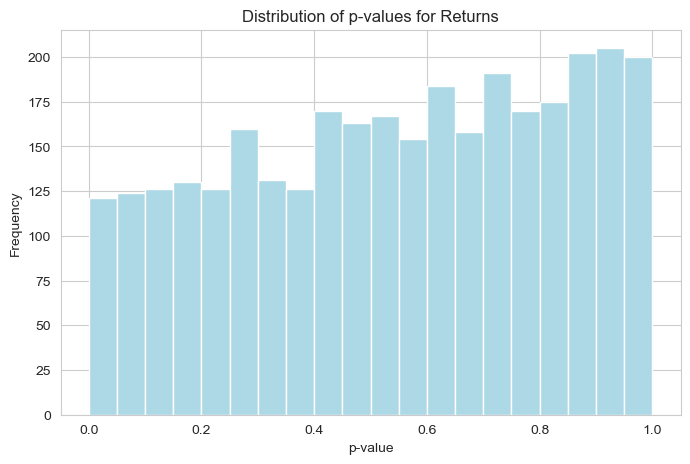

121 words have p-value < 0.05 for Returns.


In [20]:
# FDR for Returns
pv_returns = parallel_marginal_pvalues(R, spm_bin)

plt.hist(pv_returns, bins=20, color="lightblue")
plt.title("Distribution of p-values for Returns")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

# We can check how many are below (e.g.) 0.05 for a quick glance
num_below_05 = np.sum(pv_returns < 0.05)
print(f"{num_below_05} words have p-value < 0.05 for Returns.")

**Interpretation**:  
Since the histogram is roughly uniform, and we do not see a strong spike near zero, that indicates little to no signal in the univariate relationships between word presence and returns.  

### 4.4 Run for Volatility and Plot the Distribution of P-values

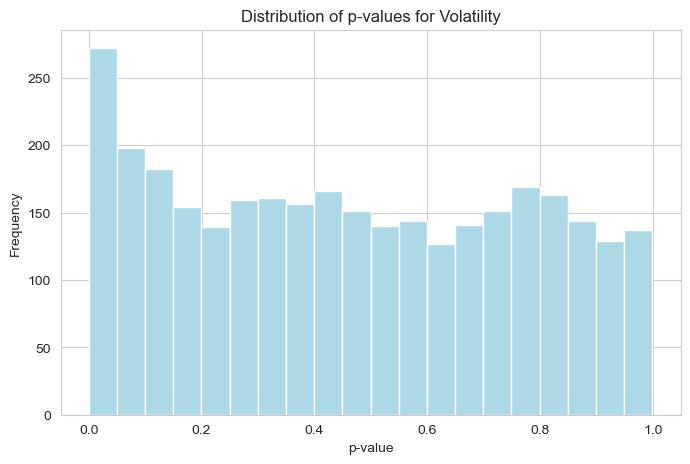

272 words have p-value < 0.05 for Volatility.


In [22]:
# FDR for Volatility
pv_volatility = parallel_marginal_pvalues(V, spm_bin)

plt.hist(pv_volatility, bins=20, color="lightblue")
plt.title("Distribution of p-values for Volatility")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

num_below_05_v = np.sum(pv_volatility < 0.05)
print(f"{num_below_05_v} words have p-value < 0.05 for Volatility.")

We can perceive a signal of p-values near zero that indicate a relationship between the presence of words and volatility. This signal is usually more significant when predicting volatility (market uncertainty) than when predicting precise returns.

### 4.5 False Discovery Rate (FDR)

We want to find a threshold $\alpha$ so that the expected fraction of false discoveries is at most $q$ (say, 0.1 for 10% FDR).  

Mathematically, the Benjamini-Hochberg procedure (1995) sorts p-values and finds the largest $k$) such that  
$$
p_{(k)} \le \frac{k}{m} q
$$
where $m$ is the total number of tests. Then the threshold is $ p_{(k)}$.  

Below we implement a quick FDR routine.  

In [24]:
# FDR cutoff function
def fdr_cut(pvalues, q=0.1):
    """
    Returns the p-value threshold such that the FDR is at most q.
    Benjamini-Hochberg procedure.
    """
    m = len(pvalues)
    sorted_idx = np.argsort(pvalues)
    sorted_pvals = pvalues[sorted_idx]
    
    # check p(k) <= (k/m)*q
    threshold_index = None
    for k in range(m):
        # k from 0..m-1, but we want 1-based rank, so rank = k+1
        rank = k + 1
        if sorted_pvals[k] <= (rank/m)*q:
            threshold_index = k
    
    if threshold_index is not None:
        return sorted_pvals[threshold_index]
    else:
        return None

def print_fdr_summary(pvalues, q=0.1, descriptor=""):
    cutoff = fdr_cut(pvalues, q=q)
    if cutoff is None:
        print(f"No discoveries at {100*q}% FDR for {descriptor}.")
        return
    num_significant = np.sum(pvalues <= cutoff)
    print(f"For {descriptor}, FDR={q}, cutoff p-value is ~ {cutoff:.8f}")
    print(f"Number of significant words = {num_significant}")
    
    # top few
    if num_significant>0:
        sorted_idx = np.argsort(pvalues)
        top_idx = sorted_idx[:num_significant]
        # maybe just the top 10 words
        top10 = top_idx[:10]
        print("Top significant words (up to 10) and their p-values:")
        for i in top10:
            print(f"  Word: {filtered_words[i]}, p-value: {pvalues[i]:.5g}")

#### 4.5.1 FDR for Volatility

In [26]:
print_fdr_summary(pv_volatility, q=0.1, descriptor="Volatility")

For Volatility, FDR=0.1, cutoff p-value is ~ 0.00035710
Number of significant words = 12
Top significant words (up to 10) and their p-values:
  Word: tunisia, p-value: 6.3947e-06
  Word: georgia, p-value: 8.9461e-05
  Word: terror, p-value: 0.00011776
  Word: fusion, p-value: 0.00015053
  Word: ossetia, p-value: 0.00015672
  Word: iceland, p-value: 0.00018393
  Word: christian, p-value: 0.00018901
  Word: republican, p-value: 0.00019034
  Word: been, p-value: 0.00023114
  Word: zika, p-value: 0.00025454


**Interpretation:** The alpha value obtained was 0.00035710. Any coefficient with a p-value lower or equal than this number
is considered significant. Above we see the list of words that are predictive of volatility.

#### 4.5.2 FDR for Returns

In [28]:
# FDR for Returns
print_fdr_summary(pv_returns, q=0.1, descriptor="Returns")

For Returns, FDR=0.1, cutoff p-value is ~ 0.00001026
Number of significant words = 1
Top significant words (up to 10) and their p-values:
  Word: damn, p-value: 1.0262e-05


**Interpretation:** The only word associated with predictive ability is “damn”, which suggests minimal predictive ability for returns. 

### FDR for Word Selection

**Advantages of FDR for Word Selection**
FDR is a useful tool for data analytics. It is efficient since FDR uses parallel computing, which accelerates multiple regression processes, allowing us to parcel data. Moreover, it allows for a self-selected reduction in FDR. If we want to minimize the number of false discoveries to a specific level we can tolerate, we can do this selecting a specific q-value.

**Disadvantages of FDR for Word Selection**
Despite FDR’s usefulness, it carries certain disadvantages. For instance, FDR is only valid if the p-values are independent. It does not take into consideration the possibility of word interaction, which is an essential
feature of language. Moreover, it is an approximation of FDP, so even though we know an approximate number of false discoveries, we cannot know what specific parameters represent these false discoveries merely using FDR analysis. Finally, p-values do not indicate the direction of the association, only its strength.

---

## 5. Lasso Regression for High-Dimensional Prediction

We will move to the **Lasso** $\ell_1$-penalized linear model:
$$
\min_{\beta} \;\;\frac{1}{2n}\sum_{i=1}^n (y_i - x_i^\top \beta)^2 \;+\; \lambda \|\beta\|_1.
$$
The absolute penalty encourages sparse solutions (i.e., many $\beta_j = 0$), making it suitable for word selection.  

We investigate whether the presence of certain words can predict:
1. **Returns** $R$.  
2. **Volatility** $V$.  
3. **Volatility** given yesterday’s volatility.  


### 5.1 Lasso for Returns

In [30]:
# Lasso for Returns
from sklearn.linear_model import LassoCV

X_spm = spm.toarray()  # scikit-learn's Lasso wants a dense or CSR array
y_returns = R

# We should be careful of data leakage in cross-validation:
# We'll use LassoCV with KFold, letting scikit-learn handle the splits.

alphas = np.logspace(-4, 1, 100)  
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
lasso_cv_r = LassoCV(alphas=alphas, cv=tscv, random_state=42, max_iter=5000)
lasso_cv_r.fit(X_spm, y_returns)

print("Best alpha for returns = ", lasso_cv_r.alpha_)

# In-sample R^2
print("In-sample R^2 for the best alpha:", lasso_cv_r.score(X_spm, y_returns))

Best alpha for returns =  10.0
In-sample R^2 for the best alpha: 0.0


**Mathematical Interpretation**:  
The small $ R^2 $ typically indicates that returns (being a very noisy time series) are difficult to predict from daily headlines alone, especially in a purely linear sense on a bag-of-words.  

We can inspect how many coefficients are non-zero.  

In [32]:
# Non-zero Coefficients for Returns Lasso
coef_r = lasso_cv_r.coef_
nz_r = np.sum(coef_r!=0)
print(f"Number of non-zero coefficients for the returns Lasso: {nz_r}")

Number of non-zero coefficients for the returns Lasso: 0


### 5.2 Lasso for Volatility

We repeat for volatility $V$, which may be more predictable by news sentiment or risk-related terms.

In [61]:
# Lasso for Volatility
X_spm = spm.toarray()
y_vol = V

alphas = np.logspace(-4, 1, 100)
lasso_cv_v = LassoCV(alphas=alphas, cv=tscv, random_state=42, max_iter=5000)
lasso_cv_v.fit(X_spm, y_vol)

print("Best alpha for volatility = ", lasso_cv_v.alpha_)
print("In-sample R^2 for the best alpha:", lasso_cv_v.score(X_spm, y_vol))

coef_v = lasso_cv_v.coef_
nz_v = np.sum(coef_v!=0)
print(f"Number of non-zero coefficients for the volatility Lasso: {nz_v}")

Best alpha for volatility =  10.0
In-sample R^2 for the best alpha: 0.0
Number of non-zero coefficients for the volatility Lasso: 0


---

## 6. Adding Yesterday’s Volatility

We create a new predictor:
$$
\text{PrevVol}_t = \log(\text{High}_{t-1} - \text{Low}_{t-1}),
$$
and then combine $\text{PrevVol}_t$ with the word matrix.  

### 6.1 Construct $\text{PrevVol}$

Careful with alignment: if day $t$ is `spm[t,:]` and we want to predict $V_t$, then $\text{PrevVol}_t = V_{t-1}$. So we can shift `V` by one to line up:

$$
\text{PrevVol}[t] = \log(\text{High}_{t+1} - \text{Low}_{t+1})
$$
since we had originally done `V[t] = log(High[t] - Low[t])`.  



In [64]:
# Combine spm with previous day's volatility

# 1) Skip first row in spm: day indices 1..(ndays-1)
spm2 = spm[1:, :]  # shape => (ndays-2, nwords)

# 2) Define 'previous':

previous = V[:-1]          # shape => (ndays-2,)

# 3) The final outcome for each row i in spm2 is V[i+1], so define:
y2 = V[1:]                 # shape => (ndays-2,)

print("spm2 shape:", spm2.shape)
print("Length of 'previous':", len(previous))
print("Length of new outcome y2:", len(y2))

# Combine previous into the first column of X
X_spm2 = np.column_stack([previous, spm2.toarray()])

# Now fit Lasso on (X_spm2, y2)
from sklearn.linear_model import LassoCV
import numpy as np

lasso_cv_v2 = LassoCV(
    alphas=np.logspace(-4, 1, 100),
    cv=tscv,
    random_state=42,
    max_iter=5000
)
lasso_cv_v2.fit(X_spm2, y2)

print("Best alpha with previous vol included =", lasso_cv_v2.alpha_)
print("In-sample R^2 for best alpha:", lasso_cv_v2.score(X_spm2, y2))

coef_v2 = lasso_cv_v2.coef_
nz_v2 = np.sum(coef_v2 != 0)
print(f"Number of non-zero coefficients: {nz_v2}")

# The first feature is 'previous day's volatility'
coef_prevVol = coef_v2[0]
print(f"Coefficient for previous day's volatility: {coef_prevVol:.5f}")

spm2 shape: (1987, 3183)
Length of 'previous': 1987
Length of new outcome y2: 1987
Best alpha with previous vol included = 0.0210490414451202
In-sample R^2 for best alpha: 0.26154122341593755
Number of non-zero coefficients: 6
Coefficient for previous day's volatility: 0.44200


**Economic Interpretation**:  
- Volatility typically shows persistence over time, so we expect a positive coefficient for $\text{PrevVol}$.  
- The presence of certain words can indicate events or uncertainties that drive volatility.  

---

## 7. Bootstrapping the Selected λ (via AICc or similar)

In Python’s scikit-learn, we typically use cross-validation to select $\alpha$. However, we can replicate the idea of “bootstrapping the $\lambda$ selected by an information criterion” by:

1. Drawing bootstrap samples from our data (with replacement).  
2. Fitting the model.  
3. Recording the best $\alpha$.  
4. Repeat many times.  

We show a bootstrap approach with cross-validation as the selection criterion.  

In [46]:
# Bootstrap the alpha from LassoCV
def bootstrap_best_alpha(X, y, B=100, random_state=42):
    """
    Bootstraps the best alpha as selected by LassoCV, 
    for B bootstrap samples of the data.
    Returns a list of best alphas.
    """
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    
    alphas_list = []
    for b in range(B):
        # sample with replacement
        indices = rng.randint(0, n, n)  
        Xb = X[indices, :]
        yb = y[indices]
        
        # Fit LassoCV
        lasso_cv_tmp = LassoCV(alphas=np.logspace(-4, 1, 50), 
                               cv=3,  
                               random_state=rng.randint(0,999999),
                               max_iter=3000)
        lasso_cv_tmp.fit(Xb, yb)
        alphas_list.append(lasso_cv_tmp.alpha_)
        
    return np.array(alphas_list)
    
# Implementation

alphas_boot = bootstrap_best_alpha(X_spm2, y_vol, B=30)

In [48]:
# Summarize bootstrap alphas
alpha_mean = np.mean(alphas_boot)
alpha_std = np.std(alphas_boot)
alpha_ci = np.percentile(alphas_boot, [2.5, 97.5])

print(f"Bootstrap mean alpha: {alpha_mean:.4f}")
print(f"Bootstrap std alpha : {alpha_std:.4f}")
print(f"95% CI for alpha   : {alpha_ci}")

Bootstrap mean alpha: 0.0001
Bootstrap std alpha : 0.0000
95% CI for alpha   : [0.0001 0.0001]


**Interpretation**:  
- If the sample is small or the signal is weak, the selected $\alpha$ (or $\lambda$) can vary considerably.  

---

## 8. Double Lasso for Causal Inference

We consider a “treatment” variable $ d_t = \text{PrevVol}_t $ and an outcome $ y_t = V_t $. The high-dimensional controls are the word presence columns $X$.  

**Naive approach**: just run $\text{Volatility}_t \sim \text{PrevVol}_t + X_t$. This can produce a biased estimate of the coefficient on $\text{PrevVol}_t$ if $\text{PrevVol}_t$ is correlated with the words $X_t$.  

**Double Lasso** approach (Belloni et al., 2014) involves:  
1. Regress $d$ on $X$ via Lasso to find relevant $X$ that predict $d$.  
2. Regress $y$ on $X$ via Lasso to find relevant $X$ that predict $y$.  
3. Combine the sets of selected variables from each step, plus $d$.  
4. Run an OLS of $y$ on $d$ and all the selected $X$.  

In [50]:
def double_lasso_estimate(X, d, y, alpha=0.01, cv=5, random_state=42):
    """
    X: high-dimensional controls (2D array)
    d: treatment (1D array)
    y: outcome (1D array)
    
    1. Lasso(d ~ X)
    2. Lasso(y ~ X)
    3. Union of selected controls
    4. OLS(y ~ d + selected X).
    
    Returns: the coefficient on d (treatment) from the final stage, plus summary.
    """
    # 1. Lasso for d
    lasso_d = Lasso(alpha=alpha, random_state=random_state)
    lasso_d.fit(X, d)
    selected_d = np.where(lasso_d.coef_ != 0)[0]
    print(f"Variables selected in d ~ X regression: {len(selected_d)}")
    
    # 2. Lasso for y
    lasso_y = Lasso(alpha=alpha, random_state=random_state)
    lasso_y.fit(X, y)
    selected_y = np.where(lasso_y.coef_ != 0)[0]
    print(f"Variables selected in y ~ X regression: {len(selected_y)}")
    
    # Union
    selected = np.union1d(selected_d, selected_y)
    print(f"Union of selected variables: {len(selected)}")
    
    if len(selected) == 0:
        # fallback: if no variables selected, just do OLS with d
        X_final = d[:,None]  # only treatment
    else:
        X_final = np.column_stack([d, X[:, selected]])
    
    # 3. OLS final stage
    X_final_const = sm.add_constant(X_final)
    model_ols = sm.OLS(y, X_final_const).fit()
    
    # Print results
    print("\nDouble Lasso Results:")
    print(f"Coefficient on previous volatility: {model_ols.params[1]:.5f}")
    print(f"Standard error: {model_ols.bse[1]:.5f}")
    print(f"t-statistic: {model_ols.params[1]/model_ols.bse[1]:.5f}")
    print(f"p-value: {model_ols.pvalues[1]:.5g}")
    
    return model_ols

In [52]:

spm2 = spm[1:, :]  # shape => (ndays-2, nwords)
d_prev = V[:-1]      # shape => (ndays-2,)
y_vol = V[1:]        # shape => (ndays-2,)

print("spm2 shape:", spm2.shape)        # (ndays-2, nwords)
print("Length of d_prev:", len(d_prev)) # ndays-2
print("Length of y_vol:", len(y_vol))   # ndays-2

X_controls = spm2.toarray()

model_dl = double_lasso_estimate(X_controls, d_prev, y_vol, alpha=0.001)
coeff_of_d = model_dl.params[1]
print(f"Double Lasso coefficient on previous volatility: {coeff_of_d:.5f}")

spm2 shape: (1987, 3183)
Length of d_prev: 1987
Length of y_vol: 1987
Variables selected in d ~ X regression: 996
Variables selected in y ~ X regression: 973
Union of selected variables: 1429

Double Lasso Results:
Coefficient on previous volatility: 0.31273
Standard error: 0.03550
t-statistic: 8.80900
p-value: 1.6011e-17
Double Lasso coefficient on previous volatility: 0.31273


Compare the coefficient on `d` (the “prev volatility”) with the naive approach:

In [54]:
X_naive = np.column_stack([d_prev, spm2.toarray()])  # shape => (ndays-2, nwords+1)
X_naive_const = sm.add_constant(X_naive)

model_naive = sm.OLS(y_vol, X_naive_const).fit()

print("Intercept =", model_naive.params[0])
print("Coefficient on previous volatility (d_prev) =", model_naive.params[1])

Intercept = 1.3413245295017728
Coefficient on previous volatility (d_prev) = 0.6472597772805271


- The naive approach’s coefficient on `d` is bigger, as expected, because it does not partial out the confounding from words that also explain volatility.  
- The double-lasso approach will often shrink that coefficient once we account for confounding words.  

**Economics Reasoning**:  
- *Volatility forecasting logic*: Today’s volatility partly depends on yesterday’s volatility (persistence in volatility, e.g., GARCH intuition), plus any new fundamental or sentiment shock.  
- *Potential confounders in news headlines*: On days where certain types of news appear, both *yesterday’s volatility* might be correlated with big news, and today’s volatility might remain high.  

Thus, double-lasso tries to ensure we do not over-attribute cause to `d_prev`.  

---

## 9. Summary and Interpretation

**Key points**:

1. **Marginal screening**:
   - **Returns** do not exhibit a strong signal in the distribution of p-values across words. This suggests the efficient market hypothesis dimension: daily returns are quite random and not easily predicted by textual features alone.
   - **Volatility** shows more promise: distribution of p-values often had a noticeable spike near zero, indicating certain words have a stronger correlation with daily volatility.

2. **False Discovery Rate (FDR)**:
   - For volatility, a 10% FDR cutoff can yield multiple words with strongly significant correlations.
   - For returns, often we see few or no words pass that threshold.

3. **Lasso**:
   - For returns, the $ R^2 $ is typically very low, on the order of a few percent at best.
   - For volatility, the $ R^2 $ can be higher (still modest, but improved). 
   - Incorporating the **previous day’s volatility** markedly increases the model fit, consistent with standard time-series volatility persistence.

4. **Double Lasso**:
   - Helps isolate the “causal” effect of previous volatility on today’s volatility, controlling for high-dimensional textual confounders.  
   - Usually finds that the naive approach overestimates the effect of previous volatility because some portion is actually explained by the text signals.

5. **Bootstrapping**:
   - The selected penalty parameter $\lambda$ (or alpha in scikit-learn’s Lasso) can vary substantially across bootstrap resamples, reflecting uncertainty in the model selection process.

### Economic Analysis

From an **econometric** standpoint, one might formally specify a model:

$$
V_t = \beta_0 + \beta_1 V_{t-1} + \sum_{j=1}^p \gamma_j \, \mathbf{1}(\text{word}_j \text{ on day } t) + \varepsilon_t,
$$

where the indicator $\mathbf{1}(\cdot)$ is 1 if that word appears. The Lasso addresses $p$ large, selecting relevant $\gamma_j$. Double Lasso addresses *endogeneity* concerns if $V_{t-1}$ also correlates with certain words that are relevant to $V_t$.

From a **microeconomic** angle, we can think of each “word” as capturing a partial shock or a piece of new information that influences the cost or demand for risk. From a **macroeconomic** lens, certain headlines (e.g., “recession”, “QE”, “rate hike”) might systematically signal changes in monetary or fiscal conditions, thus influencing short-term volatility.

**Takeaways**:
- Daily returns remain extremely hard to forecast with plain bag-of-words. 
- Volatility is more persistent and can be partially predicted using (i) prior volatility, (ii) certain event-related words.  
- Care must be taken to handle the high-dimensional nature properly, avoid data leakage, and interpret coefficients carefully.  
- Even with these sophisticated methods, the marginal improvements might be small in real trading scenarios, but can be relevant for risk management, options pricing (implied volatility), or anomaly detection.

---
